<a href="https://colab.research.google.com/github/WPHdamian/Data-Science-Curriculum-Analysis-/blob/main/B2_Market_LLM_DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset is collected from Script 'run_llama.py', datatset `scraped_jobs_llm.csv`.

In [ ]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models.phrases import Phrases, Phraser
from collections import Counter

# Download required corpora
nltk.download("stopwords")
nltk.download("wordnet")

# Load spaCy and initialize Lemmatizer
nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()
stop_words_standard = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df_all=pd.read_csv("scraped_jobs_llm.csv")
df_part=pd.read_csv("scraped_jobs_dec_llm.csv")
df_llm= pd.concat([df_all,df_part])
df2=pd.read_parquet("scraped_jobs.parquet")

In [ ]:
df_llm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5693 entries, 0 to 663
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_id            5693 non-null   int64  
 1   description       5693 non-null   object 
 2   extracted_skills  5693 non-null   object 
 3   latency           5693 non-null   float64
 4   Unnamed: 0        664 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 266.9+ KB


In [ ]:
# Drop unneeded columns
df_llm = df_llm.drop(columns=['latency', 'description','Unnamed: 0'], errors='ignore')
df_llm.head()

,job_id,extracted_skills
0,4026274969,"[""Niche recruitment"", ""Data or Tech recruitmen..."
1,4054500393,"[""Account Management"", ""Communication Planning..."
2,4065898107,"[""Java"", ""Agile development methodologies"", ""..."
3,4112637377,"[""Data analysis"", ""Product management"", ""SQL"",..."
4,4130605940,"[""Product Management"", ""Payments"", ""Fiat suppo..."


In [ ]:
# Remove unnecessary text apart from skills within `[` and `]`
df_llm["extracted_skills"]=df_llm["extracted_skills"]. apply(
    lambda x:str(x)[str(x).find('['):str(x).rfind(']')+1] if '[' in str(x) and ']' in str(x) else x
)

In [ ]:
# Check if logic applied
missing_brackets = df_llm[~(df_llm['extracted_skills'].str.contains(r'\[', na=False) & df_llm['extracted_skills'].str.contains(r'\]', na=False))]
print(f"Number of rows missing brackets: {len(missing_brackets)}")

Number of rows missing brackets: 0


In [ ]:
# merge job details with extracted skills
# Convert job_id to string in both DataFrames to ensure type matching
df2['job_id'] = df2['job_id'].astype(str)
df_llm['job_id'] = df_llm['job_id'].astype(str)

df = df2.merge(df_llm, on='job_id')
df = df.drop_duplicates(subset=['job_id'], keep='last')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4415 entries, 0 to 4894
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            4415 non-null   object
 1   keyword           4415 non-null   object
 2   location          4415 non-null   object
 3   month             4415 non-null   object
 4   title             4415 non-null   object
 5   company           4415 non-null   object
 6   detail            4415 non-null   object
 7   description       4415 non-null   object
 8   extracted_skills  4415 non-null   object
dtypes: object(9)
memory usage: 344.9+ KB


In [ ]:
# 1. Load the list of December IDs
dec_ids_df = pd.read_csv("dec_id.csv")

# 2. Ensure IDs are strings to match your main dataframe (as fixed previously)
dec_list = dec_ids_df['job_id'].astype(str).tolist()

# 3. Update the 'month' column to 'dec' for matching IDs
df.loc[df['job_id'].isin(dec_list), 'month'] = 'dec'

# 4. Verify the update
print(df['month'].value_counts())

month
nov    1907
feb    1154
jan    1144
dec     210
Name: count, dtype: int64


In [ ]:
keywords = [
    # Data Analysis & Business Analytics
    'data', 'analytics', 'analysis', 'analytical', 'statistic', 'bi', 'visualization',
    'tableau', 'power bi', 'dashboard', 'insight', 'forecast', 'kpi', 'metrics',
    # Data Science & AI
    'machine learning', 'ai', 'nlp', 'llm', 'deep learning', 'predictive', 'modeling',
    # Big Data & Data Engineering
    'big data', 'hadoop', 'spark', 'etl', 'pipeline', 'sql', 'aws', 'azure', 'gcp',
    'snowflake', 'warehouse', 'airflow', 'databricks'
]
pattern = '|'.join(keywords)

df_data = df[df['extracted_skills'].str.contains(pattern, case=False, na=False)].copy()
df_check = df[~df['extracted_skills'].str.contains(pattern, case=False, na=False)].copy()

In [ ]:
# Manually checking excluded entries to expand keyword selection if needed
df_check = df_check[['job_id','title', 'keyword', 'extracted_skills']]
df_check.to_csv("check.csv", index=False)

In [ ]:
print("Original:", len(df))
print("Filtered:", len(df_check))
print("Rentention rate:", len(df_check)/len(df))
df = df_data

Original: 4415
Filtered: 268
Rentention rate: 0.06070215175537939


6.6% of entries are removed based on keywords

In [ ]:
# Add keyword based on title (just in case)
categories = {
    "Data Engineering": r"data engineer|data engineering|etl engineer|data platform engineer",
    "Data Scientist": r"data scientist|data science|machine learning engineer|ml engineer",
    "Data Analyst": r"data analyst|data analysis|bi analyst|reporting analyst",
    "Business Analyst": r"business analyst",
    "Big Data": r"big data|hadoop|spark|pyspark|data architect"
}

for label, pattern in categories.items():
    # Mask
    mask = df["title"].str.contains(pattern, case=False, na=False)

    # Update the "keyword" column
    df.loc[mask, "keyword"] = np.where(
        df.loc[mask, "keyword"].isna(),
        label,
        df.loc[mask, "keyword"] + f", {label}"
    )

df["keyword"] = df["keyword"].apply(lambda x: ", ".join(sorted(set(x.split(", ")))) if pd.notna(x) else x)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4147 entries, 0 to 4894
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            4147 non-null   object
 1   keyword           4147 non-null   object
 2   location          4147 non-null   object
 3   month             4147 non-null   object
 4   title             4147 non-null   object
 5   company           4147 non-null   object
 6   detail            4147 non-null   object
 7   description       4147 non-null   object
 8   extracted_skills  4147 non-null   object
dtypes: object(9)
memory usage: 324.0+ KB


In [ ]:
df.to_parquet("job.parquet", index=False)
df.to_csv("job.csv", index=False)

The dataset with scraped job details and the dataset with extracted skills from job descriptions are cleaned and combined into `job.parquet`

# Section 2: EDA

In [ ]:
def parse_skills(x):
    import json, ast

    try:
        return json.loads(x)
    except:
        try:
            return ast.literal_eval(x)
        except:
            return None

df['skills_list'] = df['extracted_skills'].apply(parse_skills)

# drop affected rows
df = df[df['skills_list'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4125 entries, 0 to 4894
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            4125 non-null   object
 1   keyword           4125 non-null   object
 2   location          4125 non-null   object
 3   month             4125 non-null   object
 4   title             4125 non-null   object
 5   company           4125 non-null   object
 6   detail            4125 non-null   object
 7   description       4125 non-null   object
 8   extracted_skills  4125 non-null   object
 9   skills_list       4125 non-null   object
dtypes: object(10)
memory usage: 354.5+ KB


In [ ]:
# lowercase + strip
df['skills_list'] = df['skills_list'].apply(
    lambda x: [s.lower().strip() for s in x]
)
df['skills_doc'] = df['skills_list'].apply(lambda x: " ".join(x))

C:\Users\wongp\AppData\Local\Temp\ipykernel_27396\816892030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['skills_list'] = df['skills_list'].apply(
C:\Users\wongp\AppData\Local\Temp\ipykernel_27396\816892030.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['skills_doc'] = df['skills_list'].apply(lambda x: " ".join(x))


In [ ]:
from collections import Counter

all_skills = [skill for row in df['skills_list'] for skill in row]
skill_counts = Counter(all_skills)

# top 20
skill_counts.most_common(20)

[('python', 1118),
 ('data analysis', 868),
 ('sql', 853),
 ('communication skills', 811),
 ('communication', 717),
 ('project management', 588),
 ('collaboration', 468),
 ('stakeholder management', 413),
 ('analytical skills', 411),
 ('machine learning', 401),
 ('excel', 354),
 ('problem-solving', 341),
 ('interpersonal skills', 329),
 ('aws', 325),
 ('english', 312),
 ('leadership', 286),
 ('time management', 275),
 ('attention to detail', 261),
 ('power bi', 258),
 ('risk management', 251)]

In [ ]:
df['num_skills'] = df['skills_list'].apply(len)

df['num_skills'].describe()

C:\Users\wongp\AppData\Local\Temp\ipykernel_27396\2004814290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_skills'] = df['skills_list'].apply(len)


count    4125.000000
mean       20.727515
std         9.318845
min         4.000000
25%        14.000000
50%        19.000000
75%        25.000000
max        94.000000
Name: num_skills, dtype: float64

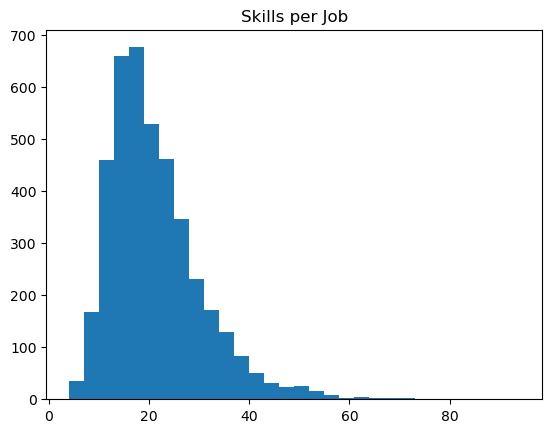

In [ ]:
plt.hist(df['num_skills'], bins=30)
plt.title("Skills per Job")
plt.show()

In [ ]:
from itertools import combinations
from collections import Counter

pair_counts = Counter()

for skills in df['skills_list']:
    for pair in combinations(set(skills), 2):
        pair_counts[pair] += 1

pair_counts.most_common(20)

[(('python', 'sql'), 553),
 (('python', 'machine learning'), 259),
 (('data analysis', 'sql'), 246),
 (('collaboration', 'communication'), 212),
 (('python', 'data analysis'), 184),
 (('communication', 'sql'), 181),
 (('project management', 'data analysis'), 176),
 (('excel', 'data analysis'), 160),
 (('power bi', 'sql'), 155),
 (('data analysis', 'communication skills'), 153),
 (('communication skills', 'analytical skills'), 153),
 (('project management', 'communication skills'), 149),
 (('communication skills', 'sql'), 140),
 (('python', 'communication skills'), 135),
 (('pytorch', 'python'), 129),
 (('sql', 'machine learning'), 128),
 (('communication', 'leadership'), 127),
 (('aws', 'sql'), 126),
 (('python', 'aws'), 125),
 (('communication', 'data analysis'), 124)]

In [ ]:
london_skills = Counter([s for row in df[df['location']=="London"]['skills_list'] for s in row])
hk_skills = Counter([s for row in df[df['location']=="Hong Kong"]['skills_list'] for s in row])

london_skills.most_common(10)
hk_skills.most_common(10)

[('communication skills', 435),
 ('data analysis', 316),
 ('project management', 311),
 ('english', 293),
 ('communication', 287),
 ('python', 257),
 ('analytical skills', 254),
 ('interpersonal skills', 228),
 ('sql', 219),
 ('collaboration', 185)]

C:\Users\wongp\AppData\Local\Temp\ipykernel_27396\3246309901.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
C:\Users\wongp\AppData\Local\Temp\ipykernel_27396\3246309901.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')


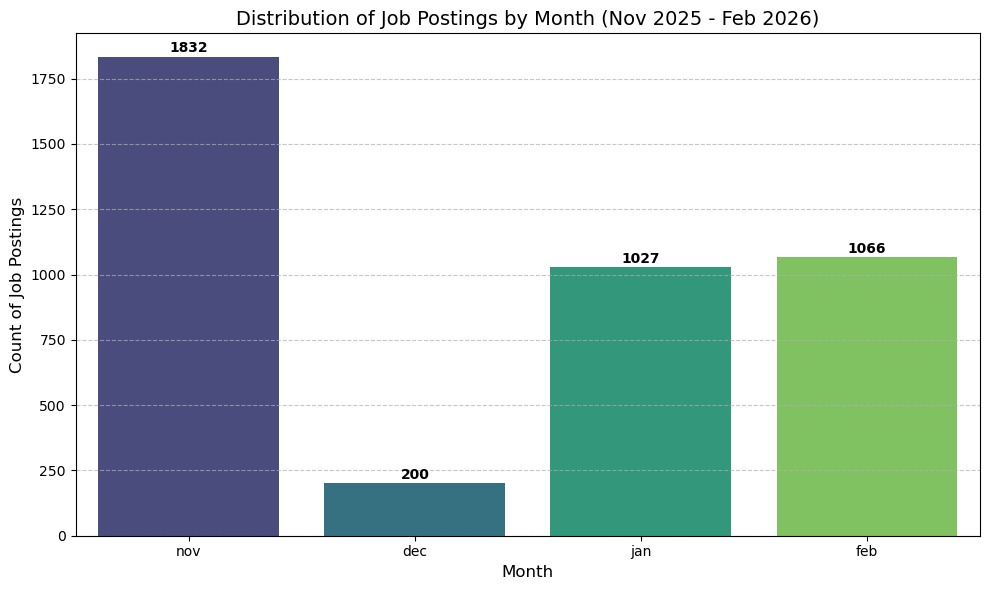

In [ ]:
# 1. Define the chronological order for the months
month_order = ['nov', 'dec', 'jan', 'feb']

# 2. Prepare the data
# We convert the column to a Categorical type to ensure the plot respects the order
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
month_counts = df['month'].value_counts().sort_index()

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')

# 4. Formatting
plt.title('Distribution of Job Postings by Month (Nov 2025 - Feb 2026)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count of Job Postings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(month_counts.values):
    plt.text(i, v + (max(month_counts.values) * 0.01), str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()